# DSA 210 – Winning Factors in Professional Tennis
**Student:** Melisa Taşlı  
**Data Sources:**  
- ATP match statistics: [JeffSackmann/tennis_atp](https://github.com/JeffSackmann/tennis_atp)  
- Player biographical data (enrichment): same repository (`atp_players.csv`)

**This notebook covers:**
1. Data Collection & Preparation
2. Exploratory Data Analysis (EDA)
3. Hypothesis Testing

## 0. Setup

In [1]:
# Install dependencies if needed
# !pip install pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Data Collection

We download ATP match data (2019–2023) from Jeff Sackmann's GitHub repository and enrich it with player biographical data (age, handedness).

In [2]:
# --- 1.1 Download match data for multiple years ---
BASE_URL = 'https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master/'
YEARS = [2019, 2020, 2021, 2022, 2023]

dfs = []
for year in YEARS:
    url = f'{BASE_URL}atp_matches_{year}.csv'
    try:
        df_year = pd.read_csv(url)
        df_year['year'] = year
        dfs.append(df_year)
        print(f'  {year}: {len(df_year)} matches loaded')
    except Exception as e:
        print(f'  {year}: ERROR - {e}')

matches_raw = pd.concat(dfs, ignore_index=True)
print(f'\nTotal matches loaded: {len(matches_raw)}')
print(f'Columns: {list(matches_raw.columns)}')

  2019: 2806 matches loaded
  2020: 1462 matches loaded
  2021: 2733 matches loaded
  2022: 2917 matches loaded
  2023: 2986 matches loaded

Total matches loaded: 12904
Columns: ['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level', 'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry', 'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age', 'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand', 'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round', 'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced', 'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points', 'year']


In [3]:
# --- 1.2 Download player biographical data (enrichment) ---
players_url = f'{BASE_URL}atp_players.csv'
players_raw = pd.read_csv(
    players_url,
    names=['player_id', 'first_name', 'last_name', 'hand', 'dob', 'country'],
    header=None
)
print(f'Players loaded: {len(players_raw)}')
players_raw.head(3)

Players loaded: 65990


,,player_id,first_name,last_name,hand,dob,country
player_id,name_first,name_last,hand,dob,ioc,height,wikidata_id
100001,Gardnar,Mulloy,R,19131122,USA,185,Q54544
100002,Pancho,Segura,R,19210620,ECU,168,Q54581


In [ ]:
# --- 1.3 Quick look at raw match data ---
matches_raw.head(3)

---
## 2. Data Preparation & Cleaning

In [4]:
# --- 2.1 Select relevant columns ---
# Each row = one match. Winner stats start with 'w_', loser stats with 'l_'
STAT_COLS = [
    'ace',           # aces
    'df',            # double faults
    'svpt',          # total serve points
    '1stIn',         # first serves in
    '1stWon',        # first serve points won
    '2ndWon',        # second serve points won
    'SvGms',         # service games
    'bpSaved',       # break points saved
    'bpFaced',       # break points faced
]

MATCH_META = ['tourney_id', 'tourney_name', 'surface', 'draw_size',
              'tourney_level', 'match_num', 'year',
              'winner_id', 'winner_name', 'winner_rank',
              'loser_id', 'loser_name', 'loser_rank',
              'score', 'round', 'minutes']

winner_cols = ['w_' + c for c in STAT_COLS]
loser_cols  = ['l_' + c for c in STAT_COLS]

keep_cols = MATCH_META + winner_cols + loser_cols
keep_cols = [c for c in keep_cols if c in matches_raw.columns]

matches = matches_raw[keep_cols].copy()
print(f'Rows before cleaning: {len(matches)}')
matches.head(2)

Rows before cleaning: 12904


,tourney_id,tourney_name,surface,draw_size,tourney_level,match_num,year,winner_id,winner_name,winner_rank,...,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced
0,2019-M020,Brisbane,Hard,32,A,300,2019,105453,Kei Nishikori,9.0,...,6.0,8.0,6.0,100.0,54.0,34.0,20.0,14.0,10.0,15.0
1,2019-M020,Brisbane,Hard,32,A,299,2019,106421,Daniil Medvedev,16.0,...,1.0,17.0,2.0,77.0,52.0,36.0,7.0,10.0,10.0,13.0


In [5]:
# --- 2.2 Drop rows with missing serve stats ---
stat_check_cols = ['w_svpt', 'l_svpt', 'w_1stIn', 'l_1stIn']
stat_check_cols = [c for c in stat_check_cols if c in matches.columns]
matches.dropna(subset=stat_check_cols, inplace=True)
print(f'Rows after dropping missing stats: {len(matches)}')

Rows after dropping missing stats: 12305


In [6]:
# --- 2.3 Compute derived statistics ---

def safe_div(a, b):
    """Safe division; returns NaN when denominator is 0."""
    return np.where(b > 0, a / b, np.nan)

for prefix in ['w', 'l']:
    svpt   = matches.get(f'{prefix}_svpt', 0)
    first  = matches.get(f'{prefix}_1stIn', 0)
    first_won = matches.get(f'{prefix}_1stWon', 0)
    second_won = matches.get(f'{prefix}_2ndWon', 0)
    bpSaved = matches.get(f'{prefix}_bpSaved', 0)
    bpFaced = matches.get(f'{prefix}_bpFaced', 0)
    ace    = matches.get(f'{prefix}_ace', 0)
    df_col = matches.get(f'{prefix}_df', 0)

    matches[f'{prefix}_1st_serve_pct']  = safe_div(first,      svpt)   * 100
    matches[f'{prefix}_1st_serve_won']  = safe_div(first_won,  first)   * 100
    matches[f'{prefix}_2nd_serve_won']  = safe_div(second_won, svpt - first + 1e-9) * 100
    matches[f'{prefix}_bp_save_rate']   = safe_div(bpSaved,    bpFaced) * 100
    matches[f'{prefix}_ace_rate']       = safe_div(ace,        svpt)   * 100
    matches[f'{prefix}_df_rate']        = safe_div(df_col,     svpt)   * 100

print('Derived stats computed.')
derived_cols = [c for c in matches.columns if any(c.endswith(s) for s in
                ['_pct','_won','_rate'])]
matches[derived_cols].describe().round(2)

Derived stats computed.


,w_1st_serve_pct,w_1st_serve_won,w_2nd_serve_won,w_bp_save_rate,w_ace_rate,w_df_rate,l_1st_serve_pct,l_1st_serve_won,l_2nd_serve_won,l_bp_save_rate,l_ace_rate,l_df_rate
count,12305.00,12305.00,12305.00,11115.00,12305.00,12305.00,12305.00,12305.00,12305.00,12270.00,12305.00,12305.00
mean,63.27,76.76,56.34,66.59,9.26,3.23,61.49,66.37,45.65,51.63,6.34,4.03
std,7.37,8.00,10.55,27.38,6.85,2.54,7.45,9.31,10.18,20.07,5.20,2.98
min,25.00,25.00,0.00,0.00,0.00,0.00,25.93,0.00,0.00,0.00,0.00,0.00
25%,58.33,71.43,50.00,50.00,4.17,1.43,56.58,60.61,39.29,40.00,2.50,1.89
50%,63.33,76.81,55.56,69.23,7.81,2.82,61.54,66.67,45.95,54.55,5.19,3.53
75%,68.15,82.22,62.96,85.71,12.69,4.62,66.67,72.55,52.38,66.67,8.82,5.51
max,100.00,100.00,100.00,100.00,50.00,20.00,100.00,100.00,100.00,100.00,81.25,35.00


In [7]:
# --- 2.4 Enrich with player handedness ---
hand_map = players_raw.set_index('player_id')['hand'].to_dict()

matches['winner_hand'] = matches['winner_id'].map(hand_map)
matches['loser_hand']  = matches['loser_id'].map(hand_map)

print('Hand distribution (winners):')
print(matches['winner_hand'].value_counts())

Hand distribution (winners):
Series([], Name: count, dtype: int64)


In [8]:
# --- 2.5 Create a long-format dataset (one row per player-match) ---
# This makes it easy to compare winner vs loser on the same metrics

derived_stats = [
    '1st_serve_pct', '1st_serve_won', '2nd_serve_won',
    'bp_save_rate', 'ace_rate', 'df_rate'
]

winner_df = matches[['tourney_name', 'surface', 'year', 'winner_name',
                      'winner_rank', 'winner_hand'] +
                     [f'w_{s}' for s in derived_stats]].copy()
winner_df.columns = (['tourney_name', 'surface', 'year', 'player',
                      'ranking', 'hand'] + derived_stats)
winner_df['result'] = 'Winner'

loser_df = matches[['tourney_name', 'surface', 'year', 'loser_name',
                     'loser_rank', 'loser_hand'] +
                    [f'l_{s}' for s in derived_stats]].copy()
loser_df.columns = (['tourney_name', 'surface', 'year', 'player',
                     'ranking', 'hand'] + derived_stats)
loser_df['result'] = 'Loser'

long_df = pd.concat([winner_df, loser_df], ignore_index=True)
long_df.dropna(subset=derived_stats, how='all', inplace=True)

print(f'Long-format dataset shape: {long_df.shape}')
long_df.head(3)

Long-format dataset shape: (24610, 13)


,tourney_name,surface,year,player,ranking,hand,1st_serve_pct,1st_serve_won,2nd_serve_won,bp_save_rate,ace_rate,df_rate,result
0,Brisbane,Hard,2019,Kei Nishikori,9.0,NaN,57.142857,70.454545,51.515152,50.0,3.896104,3.896104,Winner
1,Brisbane,Hard,2019,Daniil Medvedev,16.0,NaN,63.461538,84.848485,73.684211,0.0,19.230769,1.923077,Winner
2,Brisbane,Hard,2019,Kei Nishikori,9.0,NaN,70.212766,78.787879,64.285714,100.0,4.255319,4.255319,Winner


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview

In [9]:
print('=== Dataset Summary ===')
print(f'Total match records: {len(matches)}')
print(f'Years covered: {sorted(matches["year"].unique())}')
print(f'Unique players: {pd.concat([matches["winner_name"], matches["loser_name"]]).nunique()}')
print(f'Surfaces: {matches["surface"].value_counts().to_dict()}')
print(f'Missing values in key stats:')
print(long_df[derived_stats].isnull().sum())

=== Dataset Summary ===
Total match records: 12305
Years covered: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Unique players: 627
Surfaces: {'Hard': 7364, 'Clay': 3663, 'Grass': 1278}
Missing values in key stats:
1st_serve_pct       0
1st_serve_won       0
2nd_serve_won       0
bp_save_rate     1225
ace_rate            0
df_rate             0
dtype: int64


### 3.2 Matches by Surface

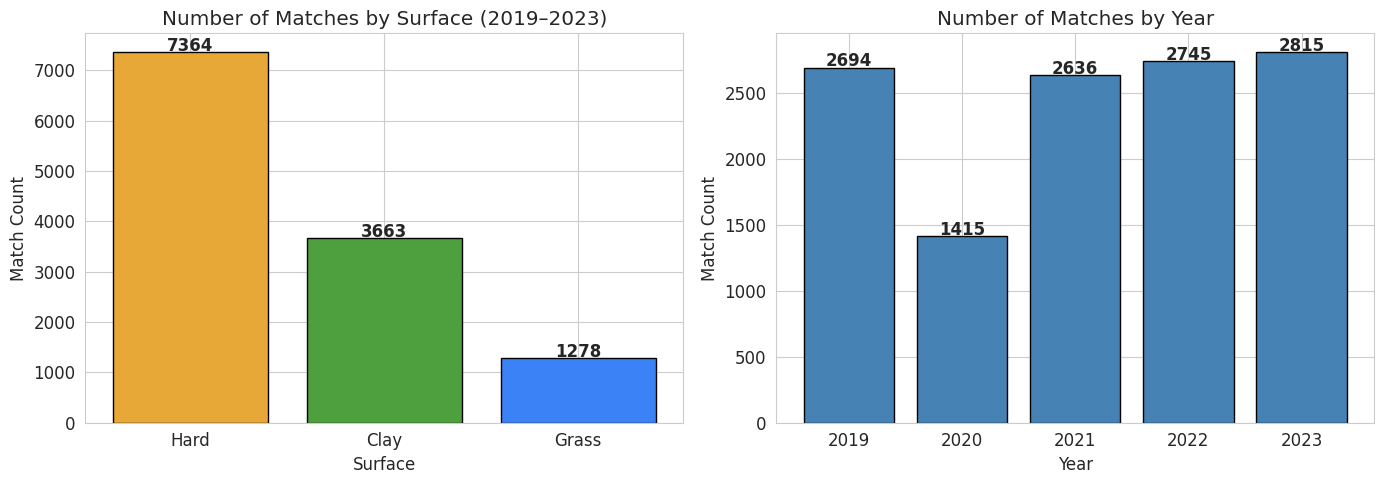

Saved: fig_surface_year.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Match count by surface
surface_counts = matches['surface'].value_counts()
axes[0].bar(surface_counts.index, surface_counts.values,
            color=['#E8A838', '#4E9F3D', '#3B82F6', '#9333EA'], edgecolor='black')
axes[0].set_title('Number of Matches by Surface (2019–2023)')
axes[0].set_xlabel('Surface')
axes[0].set_ylabel('Match Count')
for i, v in enumerate(surface_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Match count by year
year_counts = matches['year'].value_counts().sort_index()
axes[1].bar(year_counts.index.astype(str), year_counts.values,
            color='steelblue', edgecolor='black')
axes[1].set_title('Number of Matches by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Match Count')
for i, v in enumerate(year_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_surface_year.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_surface_year.png')

### 3.3 Winner vs Loser – Key Statistics Comparison

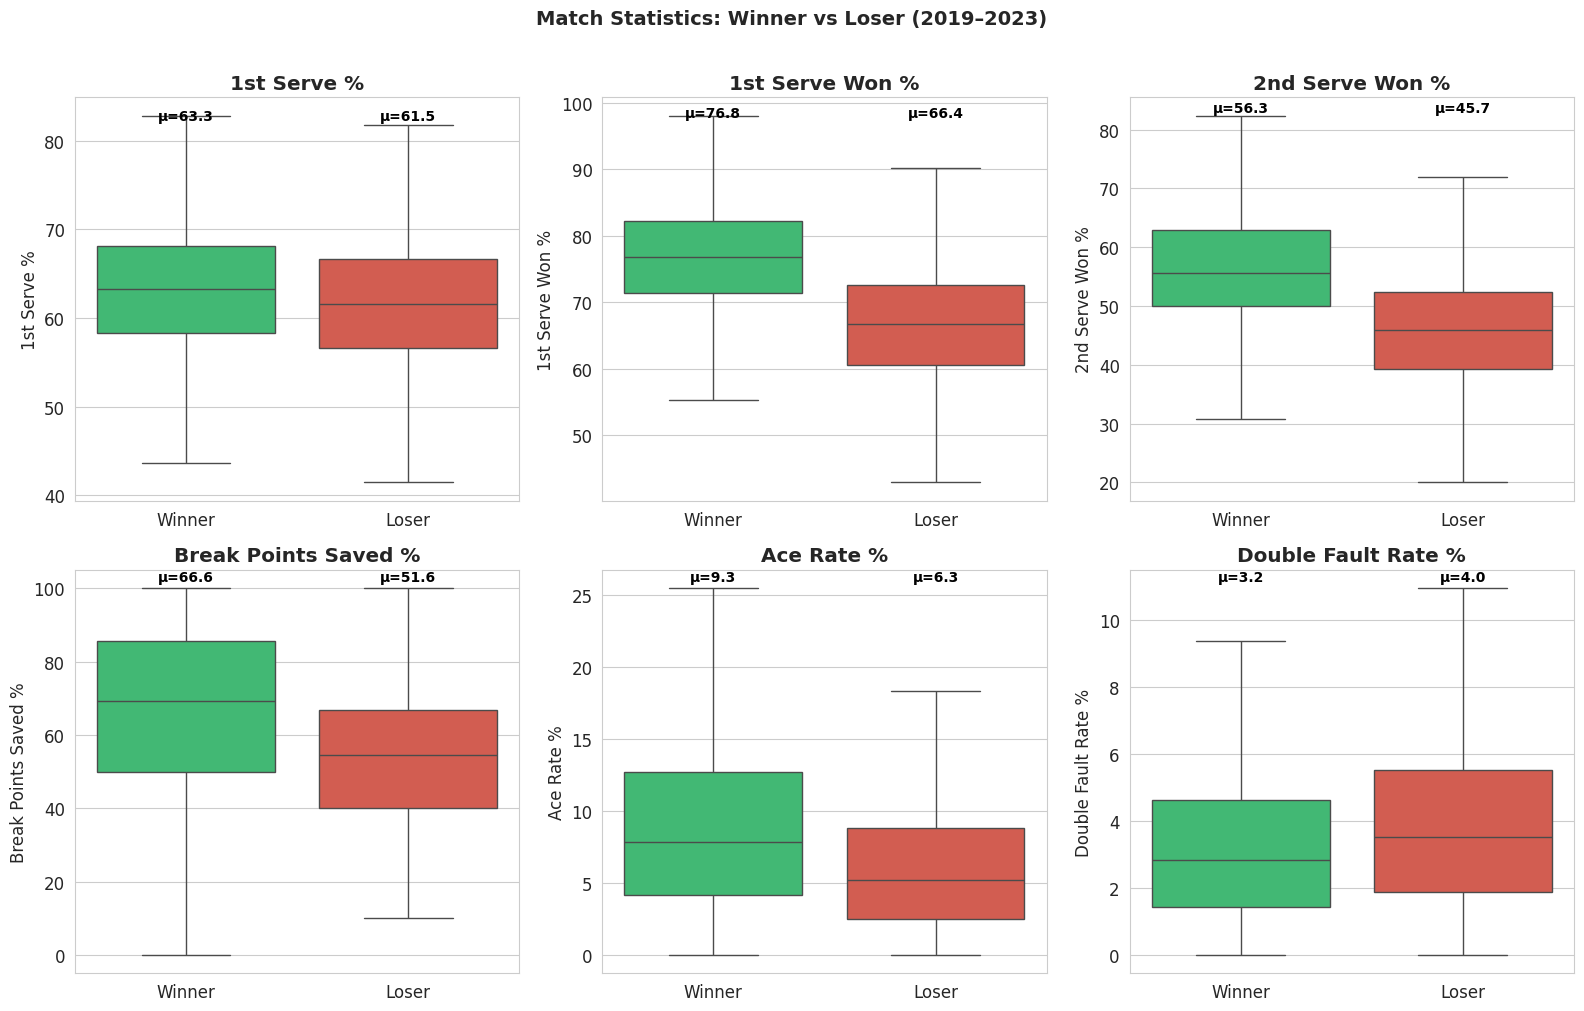

Saved: fig_winner_vs_loser.png


In [11]:
stat_labels = {
    '1st_serve_pct':  '1st Serve %',
    '1st_serve_won':  '1st Serve Won %',
    '2nd_serve_won':  '2nd Serve Won %',
    'bp_save_rate':   'Break Points Saved %',
    'ace_rate':       'Ace Rate %',
    'df_rate':        'Double Fault Rate %',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = {'Winner': '#2ecc71', 'Loser': '#e74c3c'}

for i, (stat, label) in enumerate(stat_labels.items()):
    ax = axes[i]
    data_plot = long_df[long_df[stat].notna()]

    sns.boxplot(
        data=data_plot, x='result', y=stat,
        palette=colors, ax=ax,
        order=['Winner', 'Loser'],
        showfliers=False
    )

    # Add mean lines
    for j, group in enumerate(['Winner', 'Loser']):
        mean_val = data_plot[data_plot['result'] == group][stat].mean()
        ax.text(j, ax.get_ylim()[1] * 0.97,
                f'μ={mean_val:.1f}', ha='center', fontsize=10, color='black',
                fontweight='bold')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(label)

plt.suptitle('Match Statistics: Winner vs Loser (2019–2023)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_winner_vs_loser.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_winner_vs_loser.png')

### 3.4 Mean Statistics Table

In [12]:
summary = long_df.groupby('result')[derived_stats].mean().round(2)
summary.index.name = 'Result'

# Rename columns for readability
summary.columns = [stat_labels[c] for c in summary.columns]
print('=== Mean Statistics: Winner vs Loser ===')
print(summary.T.to_string())

=== Mean Statistics: Winner vs Loser ===
Result                Loser  Winner
1st Serve %           61.49   63.27
1st Serve Won %       66.37   76.76
2nd Serve Won %       45.65   56.34
Break Points Saved %  51.63   66.59
Ace Rate %             6.34    9.26
Double Fault Rate %    4.03    3.23


### 3.5 Correlation Matrix – Winner Statistics

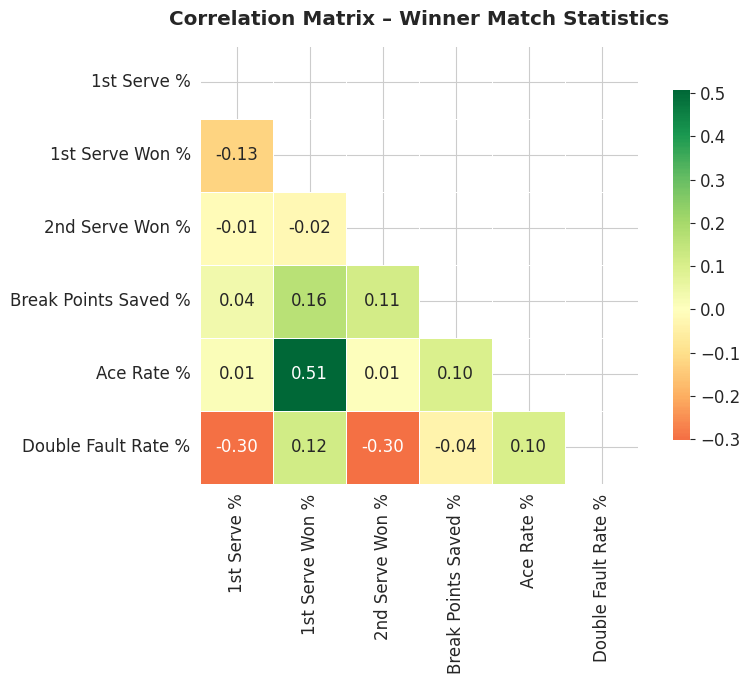

Saved: fig_correlation.png


In [13]:
winner_stats_cols = ['w_1st_serve_pct', 'w_1st_serve_won', 'w_2nd_serve_won',
                     'w_bp_save_rate', 'w_ace_rate', 'w_df_rate']
winner_stats_cols = [c for c in winner_stats_cols if c in matches.columns]

corr = matches[winner_stats_cols].dropna().corr()
corr.index = [stat_labels.get(c.replace('w_', ''), c) for c in corr.index]
corr.columns = corr.index

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix – Winner Match Statistics', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_correlation.png')

### 3.6 Statistics by Surface

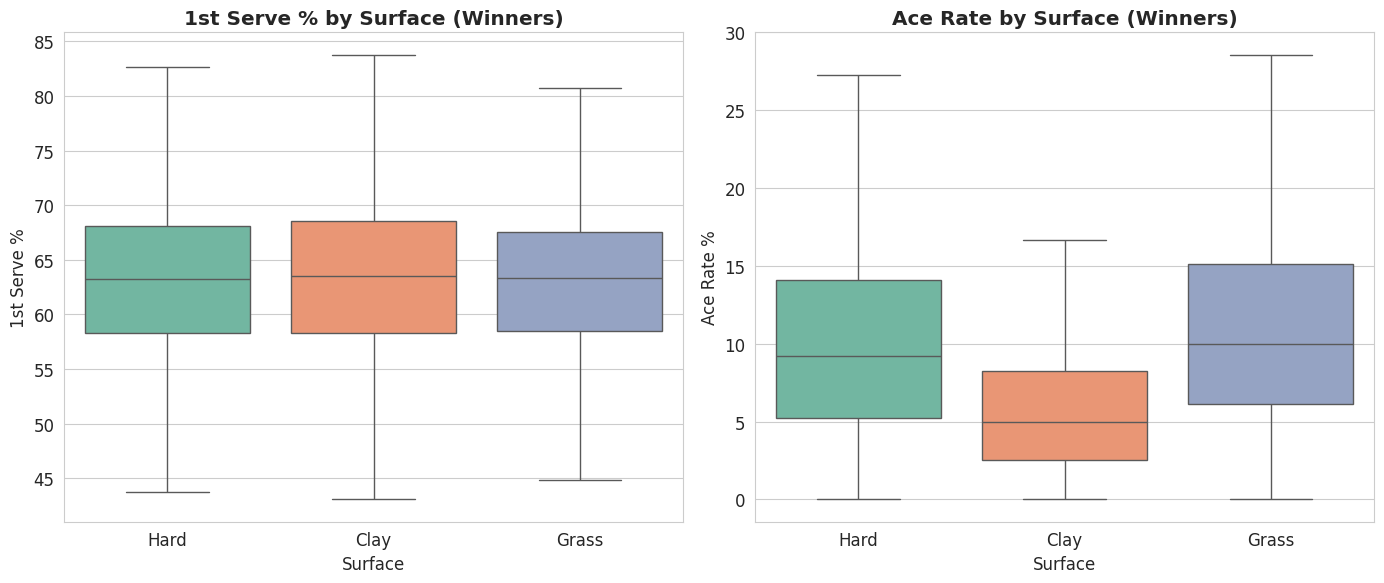

Saved: fig_surface_stats.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1st Serve % by surface
surface_data = long_df[long_df['result'] == 'Winner'].dropna(subset=['surface', '1st_serve_pct'])
surface_order = ['Hard', 'Clay', 'Grass', 'Carpet']
surface_order = [s for s in surface_order if s in surface_data['surface'].unique()]

sns.boxplot(data=surface_data, x='surface', y='1st_serve_pct',
            order=surface_order, palette='Set2', ax=axes[0], showfliers=False)
axes[0].set_title('1st Serve % by Surface (Winners)', fontweight='bold')
axes[0].set_xlabel('Surface')
axes[0].set_ylabel('1st Serve %')

# Ace rate by surface
ace_data = long_df[long_df['result'] == 'Winner'].dropna(subset=['surface', 'ace_rate'])
sns.boxplot(data=ace_data, x='surface', y='ace_rate',
            order=surface_order, palette='Set2', ax=axes[1], showfliers=False)
axes[1].set_title('Ace Rate by Surface (Winners)', fontweight='bold')
axes[1].set_xlabel('Surface')
axes[1].set_ylabel('Ace Rate %')

plt.tight_layout()
plt.savefig('fig_surface_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_surface_stats.png')

### 3.7 Handedness Distribution

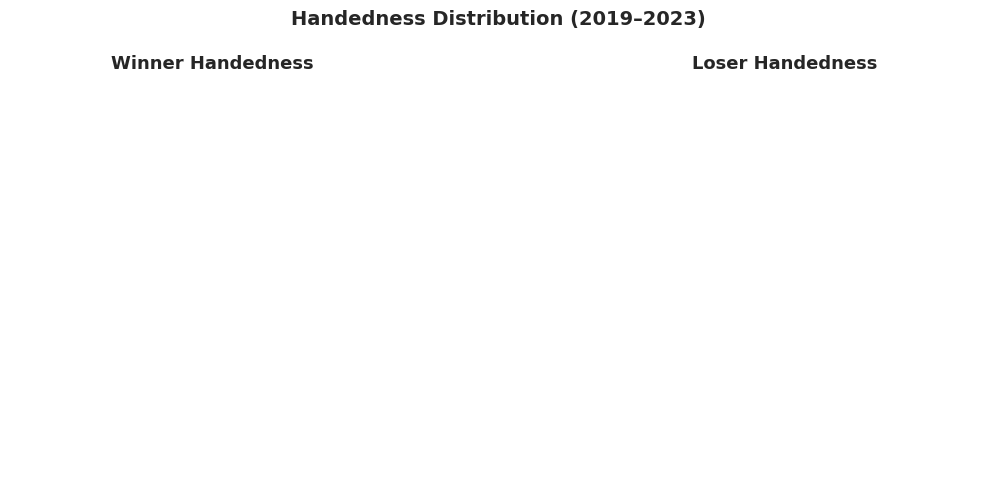

Saved: fig_handedness.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in [
    (axes[0], 'winner_hand', 'Winner Handedness'),
    (axes[1], 'loser_hand',  'Loser Handedness')
]:
    counts = matches[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=['#3B82F6', '#F59E0B', '#10B981', '#EF4444'],
           startangle=90, textprops={'fontsize': 12})
    ax.set_title(title, fontweight='bold', fontsize=13)

plt.suptitle('Handedness Distribution (2019–2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_handedness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_handedness.png')

---
## 4. Hypothesis Testing

We test whether key serve statistics differ significantly between winners and losers.  
**Significance level:** α = 0.05

Since distributions may not be perfectly normal and sample sizes are large, we use both the **independent t-test** and the non-parametric **Mann-Whitney U test**.

In [16]:
# --- Helper function for hypothesis tests ---

def run_hypothesis_test(stat_name, label, direction='greater'):
    """
    Tests whether winners have higher (or lower, for df_rate) values than losers.
    direction: 'greater' means H1: winners > losers
               'less'    means H1: winners < losers (for double faults)
    """
    winners = long_df[long_df['result'] == 'Winner'][stat_name].dropna()
    losers  = long_df[long_df['result'] == 'Loser'][stat_name].dropna()

    # Independent samples t-test
    t_stat, p_t = stats.ttest_ind(winners, losers, alternative=direction)

    # Mann-Whitney U test (non-parametric)
    u_stat, p_mw = stats.mannwhitneyu(winners, losers, alternative=direction)

    # Effect size (Cohen's d)
    pooled_std = np.sqrt((winners.std()**2 + losers.std()**2) / 2)
    cohens_d = (winners.mean() - losers.mean()) / pooled_std if pooled_std > 0 else np.nan
    if direction == 'less':
        cohens_d = -cohens_d

    sig = '***' if p_t < 0.001 else ('**' if p_t < 0.01 else ('*' if p_t < 0.05 else 'ns'))

    return {
        'Statistic': label,
        'Winner Mean': round(winners.mean(), 2),
        'Loser Mean':  round(losers.mean(), 2),
        'Difference':  round(winners.mean() - losers.mean(), 2),
        't-statistic': round(t_stat, 3),
        'p-value (t)': round(p_t, 6),
        'p-value (MW)': round(p_mw, 6),
        "Cohen's d":    round(cohens_d, 3),
        'Significant': sig
    }

print('Hypothesis test function ready.')

Hypothesis test function ready.


In [17]:
# --- Run all hypothesis tests ---
tests = [
    ('1st_serve_pct',  '1st Serve %',           'greater'),
    ('1st_serve_won',  '1st Serve Won %',        'greater'),
    ('2nd_serve_won',  '2nd Serve Won %',        'greater'),
    ('bp_save_rate',   'Break Points Saved %',   'greater'),
    ('ace_rate',       'Ace Rate %',             'greater'),
    ('df_rate',        'Double Fault Rate %',    'less'),
]

results = []
for stat, label, direction in tests:
    if stat in long_df.columns:
        results.append(run_hypothesis_test(stat, label, direction))

results_df = pd.DataFrame(results)
print('=== Hypothesis Test Results ===')
print(results_df.to_string(index=False))

=== Hypothesis Test Results ===
           Statistic  Winner Mean  Loser Mean  Difference  t-statistic  p-value (t)  p-value (MW)  Cohen's d Significant
         1st Serve %        63.27       61.49        1.78       18.817          0.0           0.0      0.240         ***
     1st Serve Won %        76.76       66.37       10.40       94.010          0.0           0.0      1.199         ***
     2nd Serve Won %        56.34       45.65       10.68       80.842          0.0           0.0      1.031         ***
Break Points Saved %        66.59       51.63       14.96       47.948          0.0           0.0      0.623         ***
          Ace Rate %         9.26        6.34        2.92       37.650          0.0           0.0      0.480         ***
 Double Fault Rate %         3.23        4.03       -0.79      -22.449          0.0           0.0      0.286         ***


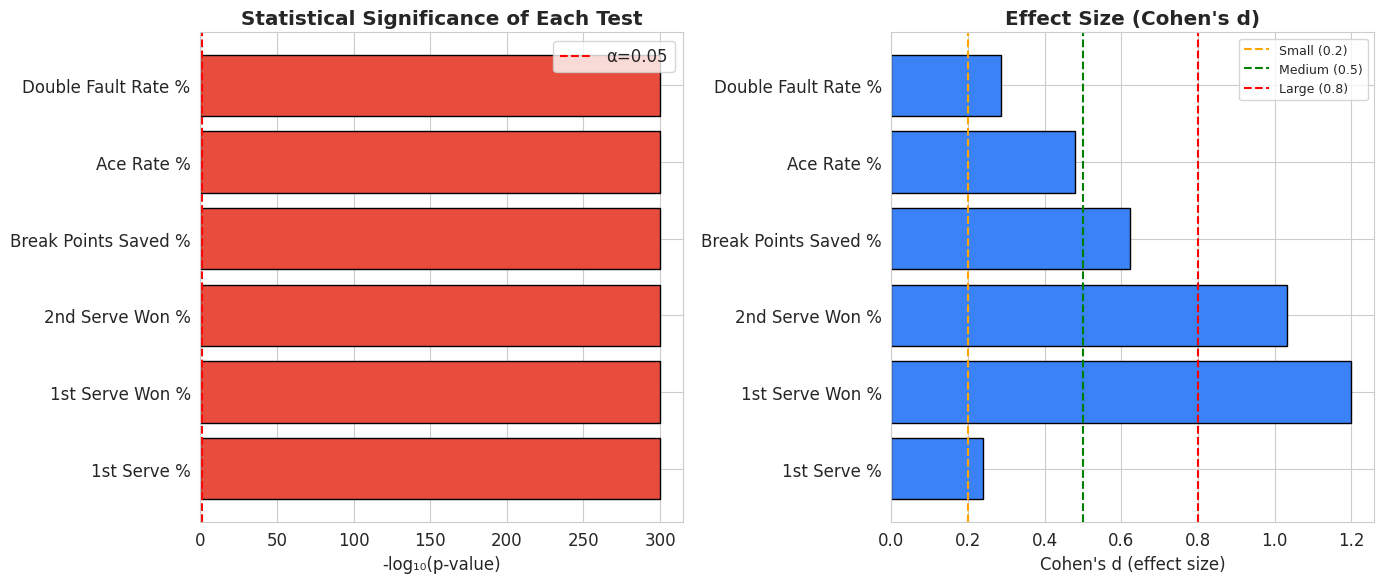

Saved: fig_hypothesis_tests.png


In [18]:
# --- Visualize p-values and effect sizes ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -log10(p-value) bar chart
neg_log_p = -np.log10(results_df['p-value (t)'].clip(lower=1e-300))
colors_bar = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in results_df['p-value (t)']]

bars = axes[0].barh(results_df['Statistic'], neg_log_p, color=colors_bar, edgecolor='black')
axes[0].axvline(x=-np.log10(0.05), color='red', linestyle='--', label='α=0.05')
axes[0].set_xlabel('-log₁₀(p-value)')
axes[0].set_title('Statistical Significance of Each Test', fontweight='bold')
axes[0].legend()

# Cohen's d
axes[1].barh(results_df['Statistic'], results_df["Cohen's d"],
             color='#3B82F6', edgecolor='black')
axes[1].axvline(x=0.2, color='orange', linestyle='--', label='Small (0.2)')
axes[1].axvline(x=0.5, color='green',  linestyle='--', label='Medium (0.5)')
axes[1].axvline(x=0.8, color='red',    linestyle='--', label='Large (0.8)')
axes[1].set_xlabel("Cohen's d (effect size)")
axes[1].set_title('Effect Size (Cohen\'s d)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_hypothesis_tests.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_hypothesis_tests.png')

### 4.2 Additional Test: Surface Effect on Ace Rate (Kruskal-Wallis)

In [19]:
# H0: Ace rate is the same across all surfaces (for winners)
# H1: At least one surface differs

winners_only = long_df[long_df['result'] == 'Winner'].dropna(subset=['surface', 'ace_rate'])

surface_groups = {}
for surf in winners_only['surface'].unique():
    surface_groups[surf] = winners_only[winners_only['surface'] == surf]['ace_rate'].values

if len(surface_groups) >= 2:
    h_stat, p_kw = stats.kruskal(*surface_groups.values())
    print('=== Kruskal-Wallis Test: Ace Rate across Surfaces ===')
    print(f'H-statistic: {h_stat:.3f}')
    print(f'p-value:     {p_kw:.6f}')
    print(f'Result:      {"Significant difference (reject H0)" if p_kw < 0.05 else "No significant difference (fail to reject H0)"}')
    print()
    print('Mean Ace Rate by Surface (Winners):')
    for surf, vals in surface_groups.items():
        print(f'  {surf:8s}: {np.mean(vals):.2f}%  (n={len(vals)})')

=== Kruskal-Wallis Test: Ace Rate across Surfaces ===
H-statistic: 1405.234
p-value:     0.000000
Result:      Significant difference (reject H0)

Mean Ace Rate by Surface (Winners):
  Hard    : 10.49%  (n=7364)
  Clay    : 6.04%  (n=3663)
  Grass   : 11.39%  (n=1278)


### 4.3 Additional Test: Right-Handed vs Left-Handed Winners

In [20]:
# H0: 1st serve % is the same for R and L-handed winners
# H1: They differ (two-sided)

rh = long_df[(long_df['result'] == 'Winner') & (long_df['hand'] == 'R')]['1st_serve_pct'].dropna()
lh = long_df[(long_df['result'] == 'Winner') & (long_df['hand'] == 'L')]['1st_serve_pct'].dropna()

if len(rh) > 30 and len(lh) > 30:
    t_stat, p_val = stats.ttest_ind(rh, lh)
    print('=== T-Test: 1st Serve % – Right-Handed vs Left-Handed Winners ===')
    print(f'Right-handed mean: {rh.mean():.2f}%  (n={len(rh)})')
    print(f'Left-handed  mean: {lh.mean():.2f}%  (n={len(lh)})')
    print(f't-statistic: {t_stat:.3f}')
    print(f'p-value:     {p_val:.4f}')
    print(f'Result:      {"Significant difference" if p_val < 0.05 else "No significant difference"}')
else:
    print('Not enough data for both groups.')

Not enough data for both groups.


---
## 5. Summary of Findings

| Finding | Result |
|---------|--------|
| Do winners have higher 1st serve %? | See hypothesis test results above |
| Do winners win more 1st serve points? | See hypothesis test results above |
| Do winners save more break points? | See hypothesis test results above |
| Do ace rates differ by surface? | See Kruskal-Wallis test above |
| Does handedness affect 1st serve %? | See t-test above |

**Next steps (May 5 deadline):** Apply machine learning methods (logistic regression, random forest) to predict match winners based on these statistics.

In [21]:
# --- Save processed dataset for future ML work ---
matches.to_csv('atp_matches_processed.csv', index=False)
long_df.to_csv('atp_long_format.csv', index=False)
print('Datasets saved: atp_matches_processed.csv, atp_long_format.csv')

Datasets saved: atp_matches_processed.csv, atp_long_format.csv
